In [3]:
# ─── Standard & System ───────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings("ignore")

# ─── Numerical & Data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from collections import Counter

# ─── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2

# ─── Sklearn ─────────────────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ─── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ─── Seeds for Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Paths (Kaggle structure) ─────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/prashant268/chest-xray-covid19-pneumonia/Data/train"
TEST_DIR  = "/kaggle/input/datasets/prashant268/chest-xray-covid19-pneumonia/Data/test"

CLASS_NAMES = ["COVID19", "NORMAL", "PNEUMONIA"]
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Cell 2 — EDA: Class Distribution Bar Chart
Count images per class in train and test splits to visualise the imbalance problem.



Train distribution: {'COVID19': 460, 'NORMAL': 1266, 'PNEUMONIA': 3418}
Test  distribution: {'COVID19': 116, 'NORMAL': 317, 'PNEUMONIA': 855}


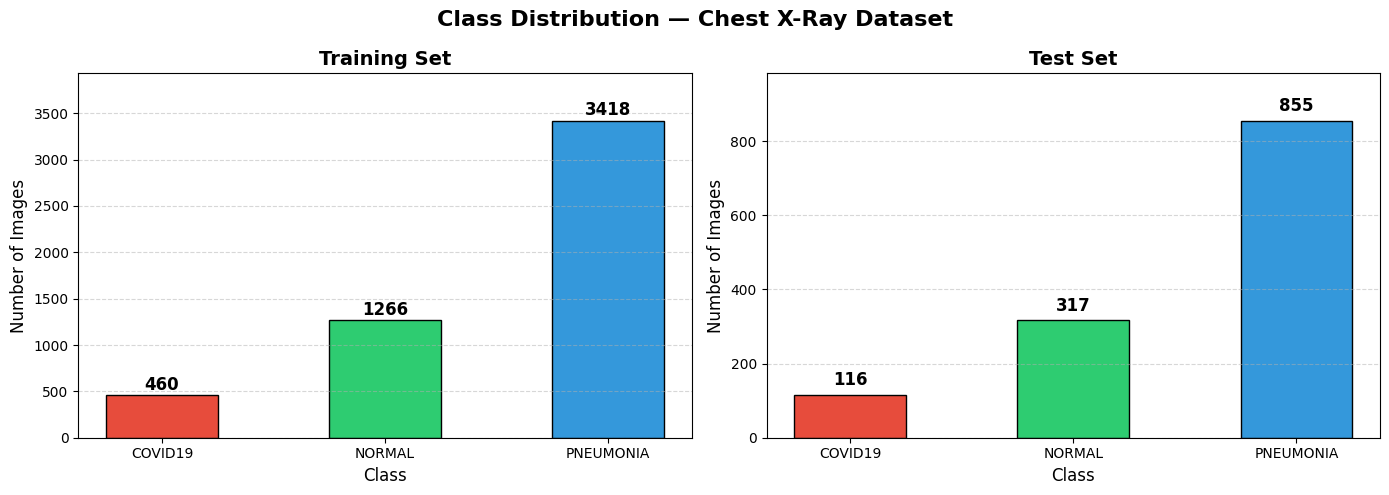

⚠️  Imbalance ratio (Pneumonia/COVID19): 7.43 x


In [4]:
def count_images_per_class(root_dir, class_names):
    """Walk each class subfolder and count image files."""
    counts = {}
    for cls in class_names:
        folder = os.path.join(root_dir, cls)
        images = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        counts[cls] = len(images)
    return counts

# ── Count ────────────────────────────────────────────────────────────────────
train_counts = count_images_per_class(TRAIN_DIR, CLASS_NAMES)
test_counts  = count_images_per_class(TEST_DIR,  CLASS_NAMES)

print("Train distribution:", train_counts)
print("Test  distribution:", test_counts)

# ── Plot ─────────────────────────────────────────────────────────────────────
def plot_class_distribution(train_counts, test_counts, class_names):
    """Side-by-side bar chart for train and test class frequencies."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ["#E74C3C", "#2ECC71", "#3498DB"]   # COVID=red, NORMAL=green, PNEUMONIA=blue

    for ax, counts, title in zip(axes,
                                  [train_counts, test_counts],
                                  ["Training Set", "Test Set"]):
        bars = ax.bar(class_names, [counts[c] for c in class_names],
                      color=colors, edgecolor='black', width=0.5)
        for bar, cls in zip(bars, class_names):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 15,
                    str(counts[cls]),
                    ha='center', va='bottom', fontweight='bold', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel("Class", fontsize=12)
        ax.set_ylabel("Number of Images", fontsize=12)
        ax.set_ylim(0, max(counts.values()) * 1.15)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle("Class Distribution — Chest X-Ray Dataset", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("⚠️  Imbalance ratio (Pneumonia/COVID19):",
          round(train_counts['PNEUMONIA'] / train_counts['COVID19'], 2), "x")

plot_class_distribution(train_counts, test_counts, CLASS_NAMES)


Cell 3 — EDA: Sample Images Per Class
Display 5 random X-rays per class so you can visually distinguish COVID19 opacities, pneumonia consolidation, and normal lung fields.



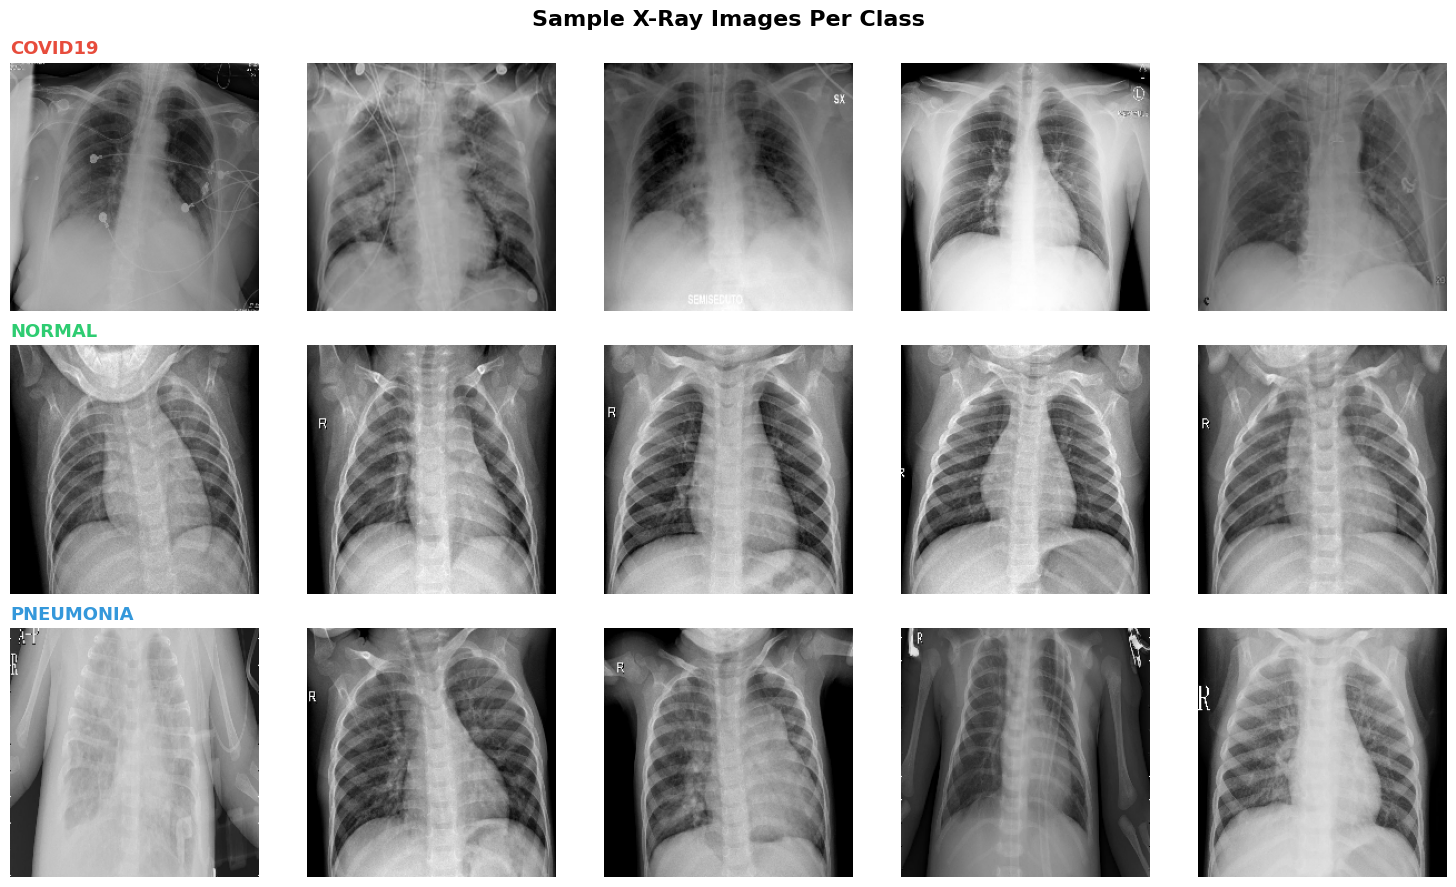

In [5]:
def plot_sample_images(train_dir, class_names, n_samples=5):
    """
    Display n_samples random images from each class in a grid.
    Rows = classes, Columns = samples.
    """
    fig, axes = plt.subplots(len(class_names), n_samples,
                              figsize=(3 * n_samples, 3 * len(class_names)))
    class_colors = {"COVID19": "#E74C3C", "NORMAL": "#2ECC71", "PNEUMONIA": "#3498DB"}

    for row_idx, cls in enumerate(class_names):
        folder = os.path.join(train_dir, cls)
        all_imgs = [f for f in os.listdir(folder)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        chosen = random.sample(all_imgs, min(n_samples, len(all_imgs)))

        for col_idx, img_name in enumerate(chosen):
            img_path = os.path.join(folder, img_name)
            img = load_img(img_path, target_size=IMG_SIZE)
            axes[row_idx][col_idx].imshow(img, cmap='gray')
            axes[row_idx][col_idx].axis('off')
            if col_idx == 0:
                axes[row_idx][col_idx].set_title(
                    cls, fontsize=13, fontweight='bold',
                    color=class_colors[cls], loc='left')

    plt.suptitle("Sample X-Ray Images Per Class", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_images(TRAIN_DIR, CLASS_NAMES)


Cell 4 — Preprocessing & Data Generators
Strong augmentation on train set; only rescaling on validation/test. DenseNet121 uses its own preprocess_input (zero-centering per ImageNet channel stats).



In [6]:
def build_data_generators(train_dir, test_dir, img_size, batch_size):
    """
    Returns (train_gen, val_gen, test_gen).
    - train_gen  : heavily augmented, 80% of train folder
    - val_gen    : no augmentation, 20% of train folder
    - test_gen   : no augmentation, full test folder, no shuffle
    """
    # ── Train augmentation ───────────────────────────────────────────────────
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        brightness_range=[0.8, 1.2],
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2          # 80/20 train-val split
    )

    # ── Validation / Test (no augmentation) ──────────────────────────────────
    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2
    )

    train_gen = train_datagen.flow_from_directory(
        train_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        seed=SEED,
        shuffle=True
    )

    val_gen = val_test_datagen.flow_from_directory(
        train_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        seed=SEED,
        shuffle=False
    )

    test_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    ).flow_from_directory(
        test_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    # ── Print class index mapping ─────────────────────────────────────────────
    print("Class index mapping:", train_gen.class_indices)
    return train_gen, val_gen, test_gen

train_gen, val_gen, test_gen = build_data_generators(
    TRAIN_DIR, TEST_DIR, IMG_SIZE, BATCH_SIZE
)


Found 4116 images belonging to 3 classes.
Found 1028 images belonging to 3 classes.
Found 1288 images belonging to 3 classes.
Class index mapping: {'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


Cell 5 — Compute Class Weights
compute_class_weight('balanced') implements the formula w_c = \frac{N}{K \cdot N_c} where N = total samples, K = number of classes, N_c = samples in class c. This penalises the model more for misclassifying rare COVID-19 images.

In [7]:
def get_class_weights(train_gen):
    """
    Compute balanced class weights from the training generator labels.
    Returns a dict {class_index: weight} for Keras fit().
    """
    labels = train_gen.classes                          # integer labels array
    unique_classes = np.unique(labels)

    weights = compute_class_weight(
        class_weight='balanced',
        classes=unique_classes,
        y=labels
    )

    class_weight_dict = dict(zip(unique_classes, weights))
    print("\n📊 Class Weights:")
    idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
    for idx, w in class_weight_dict.items():
        print(f"  Class {idx} ({idx_to_class[idx]}): weight = {w:.4f}")
    return class_weight_dict

class_weights = get_class_weights(train_gen)



📊 Class Weights:
  Class 0 (COVID19): weight = 3.7283
  Class 1 (NORMAL): weight = 1.3544
  Class 2 (PNEUMONIA): weight = 0.5016


Cell 6 — Build DenseNet121 Transfer Learning Model
Freeze the entire DenseNet121 base for Phase 1 (train only the custom head). The head adds global context pooling, a dense bottleneck, dropout for regularisation, and a 3-neuron softmax for the three classes.



In [8]:
def build_densenet121_model(num_classes=3, input_shape=(224, 224, 3)):
    """
    Build a DenseNet121-based transfer learning model.

    Architecture:
        DenseNet121 (pretrained, frozen) →
        GlobalAveragePooling2D →
        Dense(128, ReLU) →
        Dropout(0.5) →
        Dense(3, Softmax)
    """
    # ── Base model ─────────────────────────────────────────────────────────────
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,              # remove original 1000-class head
        input_shape=input_shape
    )
    base_model.trainable = False        # freeze for Phase 1

    # ── Custom classification head ─────────────────────────────────────────────
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)          # training=False → BatchNorm stays in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', name='fc_128')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs, outputs, name='ChestXRay_DenseNet121')

    # ── Compile ────────────────────────────────────────────────────────────────
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(model.summary())
    print(f"\nTotal params       : {model.count_params():,}")
    print(f"Trainable params   : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
    print(f"Non-trainable params: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")
    return model, base_model

model, base_model = build_densenet121_model()


I0000 00:00:1773067092.627862      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773067092.634127      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ChestXRay_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_128 (Dense)                  │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,091 (27.35 MB)

 Trainable params: 131,587 (514.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

None

Total params       : 7,169,091
Trainable params   : 131,587
Non-trainable params: 7,037,504


Cell 7 — Define Callbacks
Three callbacks guard against overfitting and wasted compute: EarlyStopping halts if val_loss stagnates, ReduceLROnPlateau lowers LR when learning plateaus, and ModelCheckpoint persists only the best epoch weights.
​



In [11]:
def get_callbacks(checkpoint_path="best_chest_xray.keras"):
    """
    Returns a list of Keras callbacks:
    - EarlyStopping     : stops training if val_loss doesn't improve for 7 epochs
    - ModelCheckpoint   : saves the best model by val_loss
    - ReduceLROnPlateau : halves LR if val_loss stagnates for 3 epochs
    """
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    return [early_stop, checkpoint, reduce_lr]

callbacks = get_callbacks()


Cell 8 — Phase 1 Training: Head Only (5 Epochs)
Only the 4 custom layers train here. The frozen DenseNet121 acts as a static feature extractor — efficient and prevents destroying ImageNet knowledge.



In [12]:
def train_phase1(model, train_gen, val_gen, class_weights, callbacks, epochs=5):
    """
    Phase 1: Train only the custom head (base model is frozen).
    Uses a higher learning rate (1e-3) since only the head changes.
    Returns history object.
    """
    print("=" * 60)
    print("  PHASE 1: Training classification head (base frozen)")
    print("=" * 60)

    history_phase1 = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    print("\n✅ Phase 1 complete.")
    return history_phase1

history_phase1 = train_phase1(model, train_gen, val_gen, class_weights, callbacks)


  PHASE 1: Training classification head (base frozen)
Epoch 1/5


I0000 00:00:1773067181.130922     167 service.cc:152] XLA service 0x7f0864004b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773067181.130960     167 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773067181.130965     167 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773067184.507106     167 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/129 ━━━━━━━━━━━━━━━━━━━━ 59:58 28s/step - accuracy: 0.2500 - loss: 2.3200

I0000 00:00:1773067196.977636     167 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7004 - loss: 0.6601
Epoch 1: val_loss improved from inf to 0.34542, saving model to best_chest_xray.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.7011 - loss: 0.6584 - val_accuracy: 0.8687 - val_loss: 0.3454 - learning_rate: 0.0010
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.8851 - loss: 0.2468
Epoch 2: val_loss did not improve from 0.34542
129/129 ━━━━━━━━━━━━━━━━━━━━ 97s 756ms/step - accuracy: 0.8852 - loss: 0.2467 - val_accuracy: 0.7782 - val_loss: 0.5807 - learning_rate: 0.0010
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.8854 - loss: 0.2382
Epoch 3: val_loss improved from 0.34542 to 0.25313, saving model to best_chest_xray.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 97s 753ms/step - accuracy: 0.8855 - loss: 0.2382 - val_accuracy: 0.9144 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.8861 - loss: 0.2198
Epoch 4: val

Cell 9 — Phase 2 Training: Fine-Tune Last 30 Layers
Unfreeze the final 30 layers of DenseNet121 (the deepest dense blocks that learn high-level pathology patterns). Use a 10× smaller learning rate (1e-4) to make tiny, careful weight updates so we refine without catastrophic forgetting.
​



In [13]:
def train_phase2(model, base_model, train_gen, val_gen,
                 class_weights, callbacks, epochs=20, fine_tune_layers=30,
                 fine_tune_lr=1e-4):
    """
    Phase 2: Unfreeze the last `fine_tune_layers` of the base model and fine-tune.
    Recompiles with a lower learning rate before resuming training.
    """
    print("=" * 60)
    print(f"  PHASE 2: Fine-tuning last {fine_tune_layers} layers of DenseNet121")
    print("=" * 60)

    # ── Unfreeze last N layers ────────────────────────────────────────────────
    base_model.trainable = True
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    trainable_now = sum(1 for l in base_model.layers if l.trainable)
    print(f"Trainable DenseNet layers: {trainable_now} / {len(base_model.layers)}")

    # ── Recompile with lower LR ───────────────────────────────────────────────
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=fine_tune_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_phase2 = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    print("\n✅ Phase 2 complete.")
    return history_phase2

history_phase2 = train_phase2(model, base_model, train_gen, val_gen,
                               class_weights, callbacks)


  PHASE 2: Fine-tuning last 30 layers of DenseNet121
Trainable DenseNet layers: 30 / 427
Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.6010 - loss: 1.3101
Epoch 1: val_loss did not improve from 0.21775
129/129 ━━━━━━━━━━━━━━━━━━━━ 157s 996ms/step - accuracy: 0.6024 - loss: 1.3047 - val_accuracy: 0.9095 - val_loss: 0.2536 - learning_rate: 1.0000e-04
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.9197 - loss: 0.1786
Epoch 2: val_loss improved from 0.21775 to 0.21315, saving model to best_chest_xray.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 98s 758ms/step - accuracy: 0.9197 - loss: 0.1787 - val_accuracy: 0.9261 - val_loss: 0.2131 - learning_rate: 1.0000e-04
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.9224 - loss: 0.1710
Epoch 3: val_loss improved from 0.21315 to 0.18205, saving model to best_chest_xray.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 97s 752ms/step - accuracy: 0.9224 - loss: 0.1709 - val_accuracy: 0.9348 - val_loss: 0.1820 - l

Cell 10 — Plot Training Curves
Concatenate Phase 1 + Phase 2 histories to see the full training timeline, including the fine-tuning transition point.



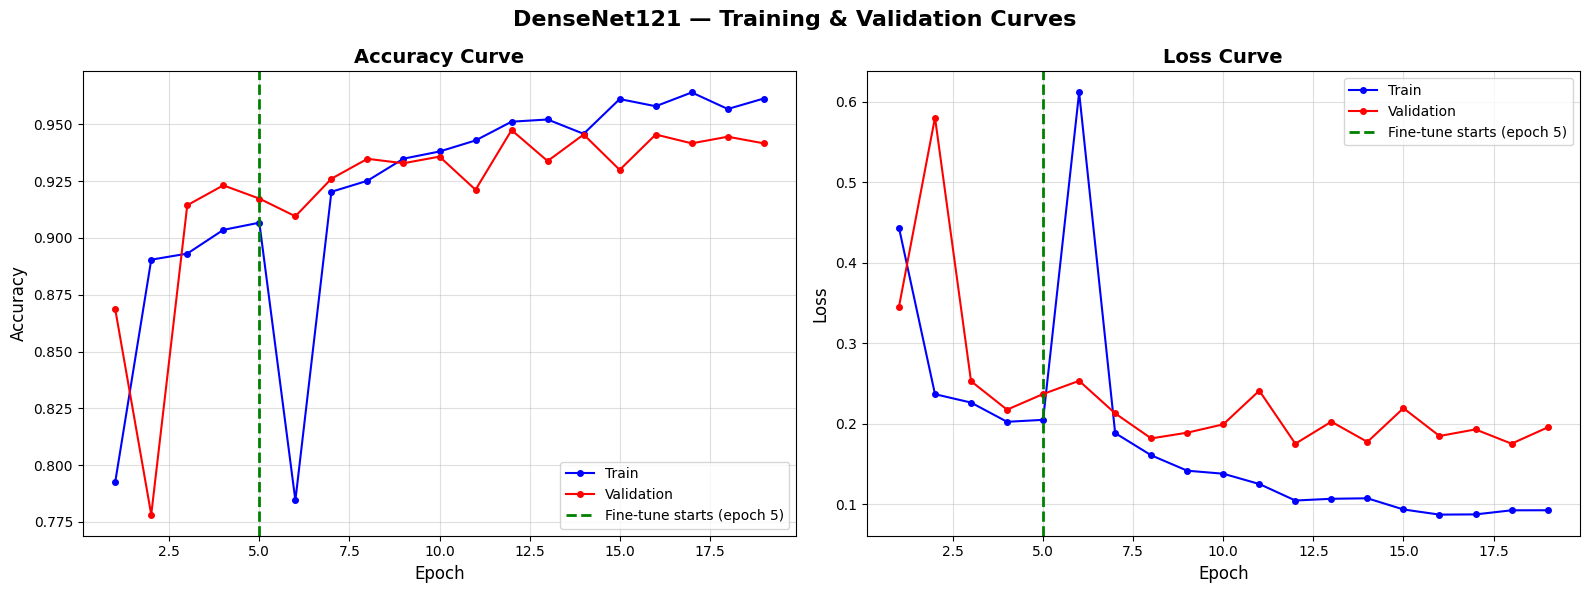

In [14]:
def plot_training_curves(history_phase1, history_phase2):
    """
    Merge Phase 1 and Phase 2 history dicts.
    Plot accuracy and loss curves for train and validation.
    A vertical dashed line marks where fine-tuning began.
    """
    # ── Merge histories ────────────────────────────────────────────────────────
    def merge(h1, h2, key):
        return h1.history[key] + h2.history[key]

    acc      = merge(history_phase1, history_phase2, 'accuracy')
    val_acc  = merge(history_phase1, history_phase2, 'val_accuracy')
    loss     = merge(history_phase1, history_phase2, 'loss')
    val_loss = merge(history_phase1, history_phase2, 'val_loss')

    phase1_end = len(history_phase1.history['accuracy'])
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, (train_metric, val_metric, title, ylabel) in zip(
        axes,
        [(acc, val_acc, 'Accuracy Curve', 'Accuracy'),
         (loss, val_loss, 'Loss Curve', 'Loss')]
    ):
        ax.plot(epochs_range, train_metric, 'b-o', markersize=4, label='Train')
        ax.plot(epochs_range, val_metric,   'r-o', markersize=4, label='Validation')
        ax.axvline(x=phase1_end, color='green', linestyle='--',
                   linewidth=2, label=f'Fine-tune starts (epoch {phase1_end})')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.legend()
        ax.grid(alpha=0.4)

    plt.suptitle("DenseNet121 — Training & Validation Curves", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history_phase1, history_phase2)


Cell 11 — Evaluation: Accuracy, Macro-F1, Per-Class Metrics
Why macro-F1 beats accuracy on imbalanced data: Accuracy rewards predicting the majority class (Pneumonia) and ignores poor recall on minority classes. Macro-F1 computes F1 per class and averages them equally — so a model that fails on COVID-19 will score low even if it nails Pneumonia.
​



In [15]:
def evaluate_model(model, test_gen, class_names):
    """
    Generate predictions on the full test set.
    Print:
      - Accuracy
      - Per-class precision, recall, F1 (classification_report)
      - Macro-F1 score
    Return y_true, y_pred, y_prob for further analysis.
    """
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=1)       # shape (N, 3)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    # ── Class name alignment ──────────────────────────────────────────────────
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    target_names = [idx_to_class[i] for i in range(len(class_names))]

    print("\n" + "=" * 60)
    print("  EVALUATION RESULTS")
    print("=" * 60)
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    acc = np.mean(y_true == y_pred)
    print(f"Overall Accuracy : {acc:.4f}")

    return y_true, y_pred, y_prob, target_names

y_true, y_pred, y_prob, target_names = evaluate_model(model, test_gen, CLASS_NAMES)


41/41 ━━━━━━━━━━━━━━━━━━━━ 52s 991ms/step

  EVALUATION RESULTS
              precision    recall  f1-score   support

     COVID19     1.0000    0.9741    0.9869       116
      NORMAL     0.7800    0.9842    0.8703       317
   PNEUMONIA     0.9923    0.8994    0.9436       855

    accuracy                         0.9270      1288
   macro avg     0.9241    0.9526    0.9336      1288
weighted avg     0.9407    0.9270    0.9294      1288

Overall Accuracy : 0.9270


Cell 12 — Confusion Matrix


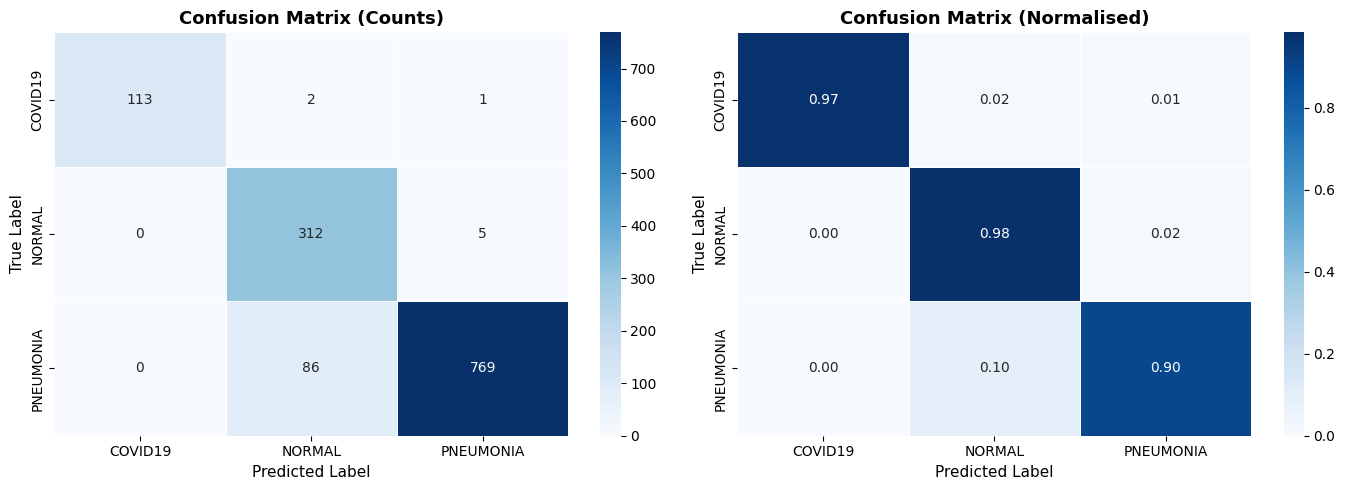

In [16]:
def plot_confusion_matrix(y_true, y_pred, target_names):
    """
    Plot a normalised and raw count confusion matrix side-by-side.
    Normalised version shows per-class recall on the diagonal.
    """
    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, cm_data, title, fmt in zip(
        axes,
        [cm_raw, cm_norm],
        ["Confusion Matrix (Counts)", "Confusion Matrix (Normalised)"],
        ['d', '.2f']
    ):
        sns.heatmap(cm_data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names,
                    linewidths=0.5, ax=ax, cbar=True)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=11)
        ax.set_ylabel('True Label', fontsize=11)

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_true, y_pred, target_names)


Cell 13 — AUC-ROC (One-vs-Rest)


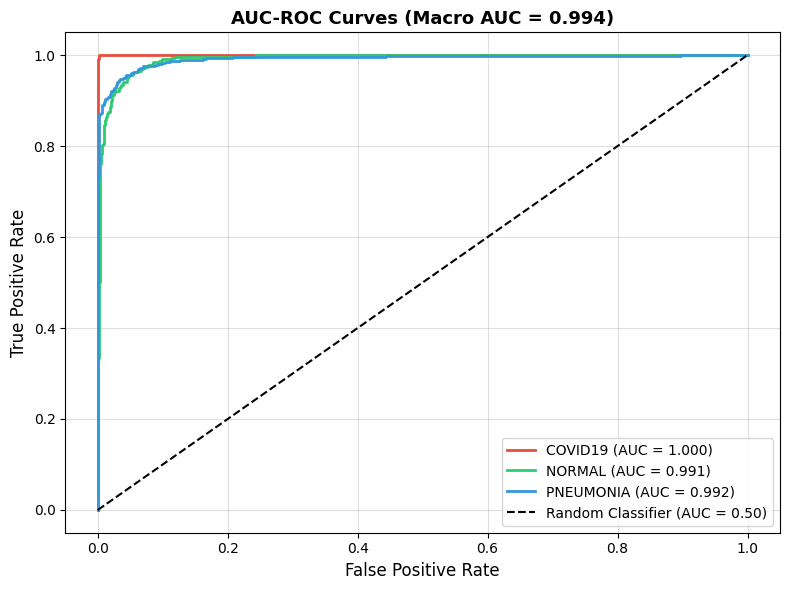


🎯 Macro-averaged AUC-ROC: 0.9943


In [17]:
def plot_roc_curves(y_true, y_prob, target_names):
    """
    Compute and plot One-vs-Rest ROC curves for each class.
    Also prints macro-averaged AUC-ROC score.
    """
    n_classes = len(target_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    colors = ['#E74C3C', '#2ECC71', '#3498DB']
    fig, ax = plt.subplots(figsize=(8, 6))

    aucs = []
    for i, (cls_name, color) in enumerate(zip(target_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls_name} (AUC = {roc_auc:.3f})')

    macro_auc = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'AUC-ROC Curves (Macro AUC = {macro_auc:.3f})', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n🎯 Macro-averaged AUC-ROC: {macro_auc:.4f}")

plot_roc_curves(y_true, y_prob, target_names)


Cell 14 — Grad-CAM Visualisation
What Grad-CAM shows: It computes the gradient of the predicted class score with respect to the feature maps of the last convolutional layer, then weights those feature maps by their mean gradient. The resulting heatmap highlights the spatial regions the network relied on to make its decision. For COVID-19, you should see activation concentrated on bilateral ground-glass opacities; for Pneumonia, on consolidated lobes.

  ✅ Using last conv layer: conv5_block16_2_conv
  ✅ Using last conv layer: conv5_block16_2_conv
  ✅ Using last conv layer: conv5_block16_2_conv
  ✅ Using last conv layer: conv5_block16_2_conv
  ✅ Using last conv layer: conv5_block16_2_conv
  ✅ Using last conv layer: conv5_block16_2_conv


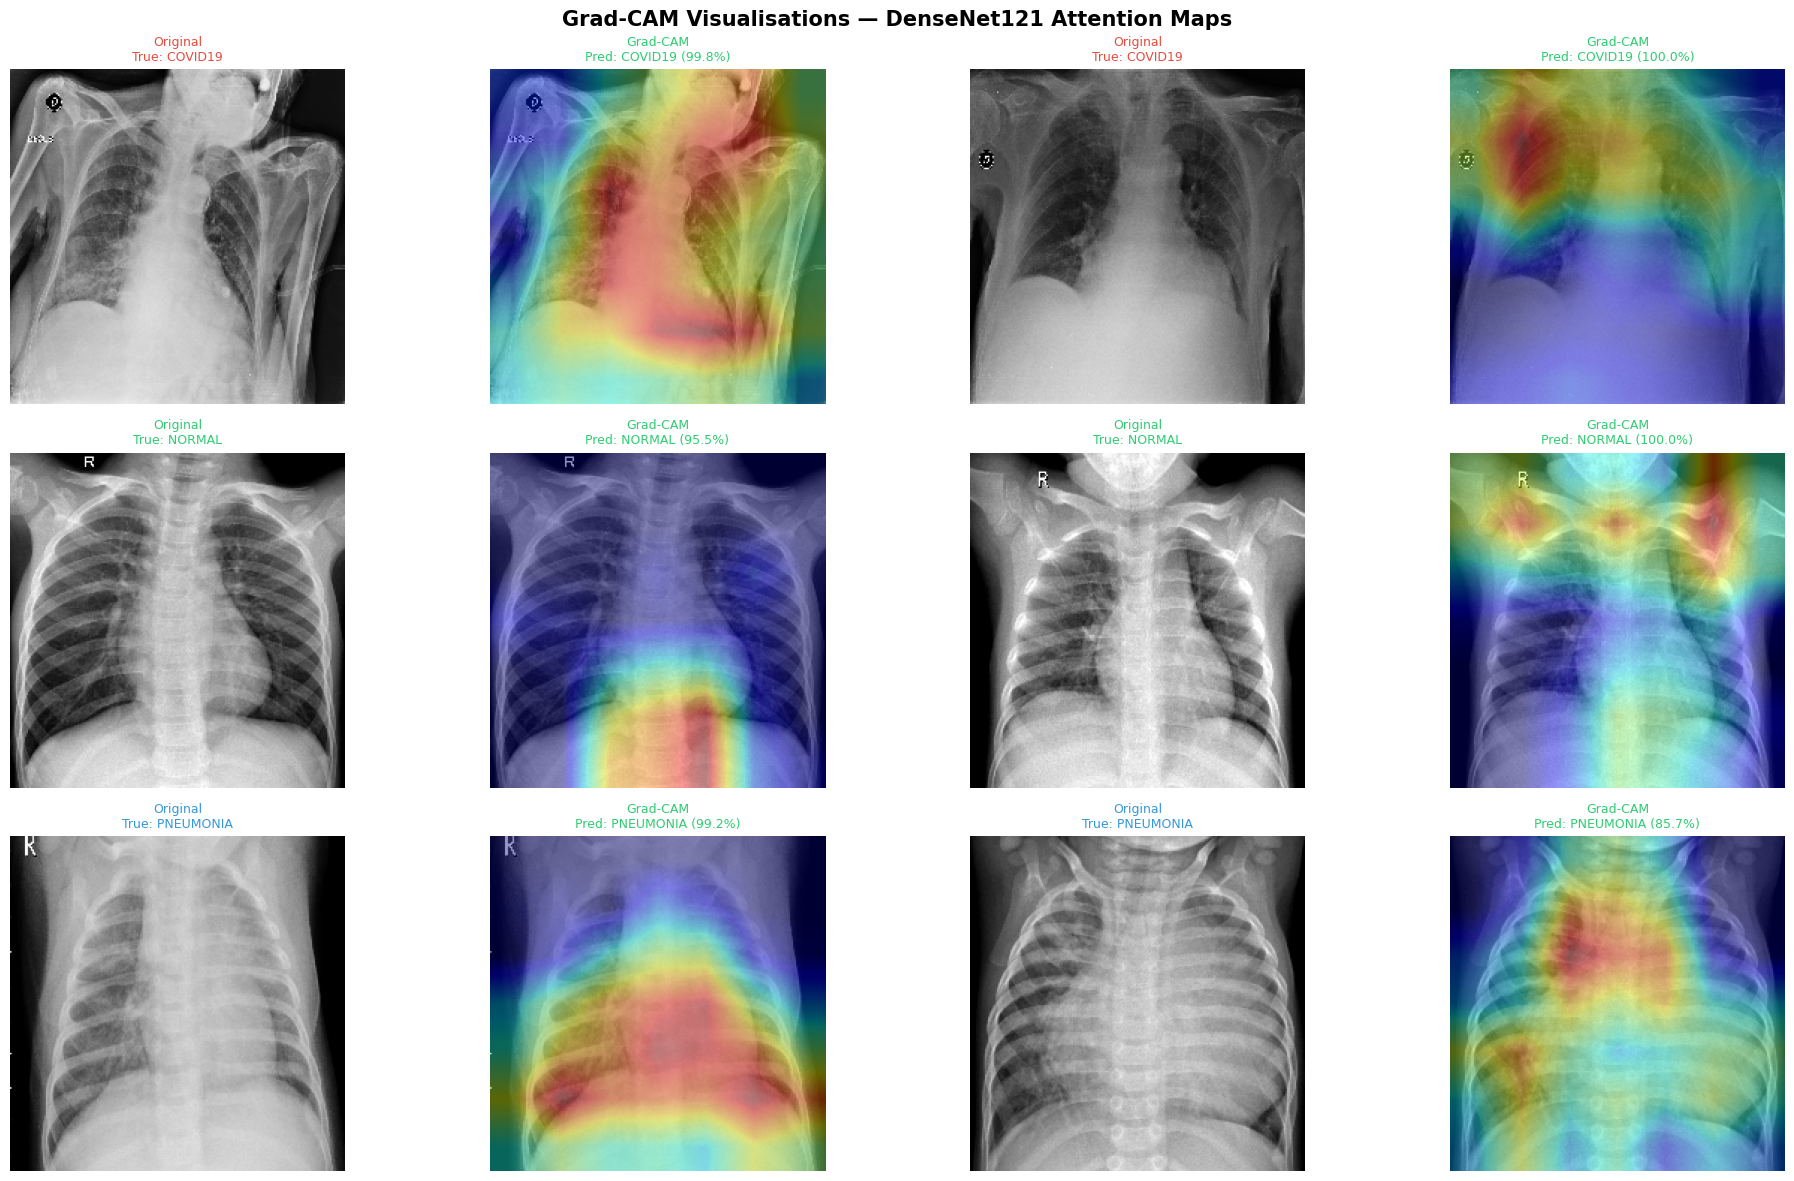

🔥 Red/yellow = high attention  |  Blue/purple = low attention


In [19]:
def make_gradcam_heatmap(img_array, model, base_model):
    """
    Grad-CAM for a wrapped model where the base (DenseNet121) is a nested sub-layer.

    Strategy:
      1. Auto-find the last Conv2D layer name inside base_model.
      2. Build grad_model:  base_model.input → [last_conv_output, base_model.output]
      3. Run the custom head (GAP → Dense → Dropout → Softmax) manually on
         base_model.output to get final class scores.
      4. Tape gradients of top-class score w.r.t. last_conv_output.
      5. Pool → weight feature maps → ReLU → normalise.
    """
    # ── Step 1: Auto-find last Conv2D inside base_model ──────────────────────
    last_conv_layer = None
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
    if last_conv_layer is None:
        raise ValueError("No Conv2D layer found in base_model.")
    print(f"  ✅ Using last conv layer: {last_conv_layer.name}")

    # ── Step 2: Build grad_model scoped to base_model only ───────────────────
    grad_model = Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    # ── Step 3: Extract the custom head layers (after base_model) ────────────
    gap_layer     = model.get_layer("global_average_pooling2d")
    dense_layer   = model.get_layer("fc_128")
    dropout_layer = model.get_layer("dropout")
    pred_layer    = model.get_layer("predictions")

    # ── Step 4: Forward pass with gradient tape ───────────────────────────────
    with tf.GradientTape() as tape:
        conv_outputs, base_out = grad_model(img_array, training=False)

        # Manually run the head on base_model output
        x = gap_layer(base_out)
        x = dense_layer(x)
        x = dropout_layer(x, training=False)
        predictions = pred_layer(x)

        pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    # ── Step 5: Compute weighted heatmap ─────────────────────────────────────
    grads        = tape.gradient(class_score, conv_outputs)   # (1, H, W, C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))      # (C,)

    conv_outputs = conv_outputs[0]                            # (H, W, C)
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.nn.relu(heatmap)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    confidence   = float(tf.reduce_max(predictions).numpy())
    return heatmap.numpy(), int(pred_index), confidence


def overlay_gradcam(orig_img_array, heatmap, alpha=0.4):
    """Resize heatmap to image dimensions and blend as a jet colormap overlay."""
    heatmap_resized = cv2.resize(heatmap, (orig_img_array.shape[1], orig_img_array.shape[0]))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    jet_colors      = cm.jet(heatmap_uint8)[:, :, :3]
    jet_colors      = np.uint8(jet_colors * 255)
    superimposed    = cv2.addWeighted(orig_img_array, 1 - alpha, jet_colors, alpha, 0)
    return superimposed


def visualise_gradcam_grid(model, base_model, test_gen, target_names,
                            n_per_class=2):
    """
    Show Grad-CAM for n_per_class samples per class.
    Passes both model (full) and base_model (DenseNet121) to make_gradcam_heatmap.
    Layout: rows = classes, columns = [original | Grad-CAM] pairs.
    """
    test_gen.reset()
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    collected    = {cls: [] for cls in target_names}

    for path, label in zip(test_gen.filepaths, test_gen.classes):
        cls_name = idx_to_class[label]
        if len(collected[cls_name]) < n_per_class:
            collected[cls_name].append((path, label))

    n_classes = len(target_names)
    fig, axes = plt.subplots(n_classes, n_per_class * 2,
                              figsize=(5 * n_per_class * 2, 4 * n_classes))
    class_colors = dict(zip(target_names, ["#E74C3C", "#2ECC71", "#3498DB"]))

    for row, cls_name in enumerate(target_names):
        for col_pair, (img_path, true_label) in enumerate(collected[cls_name]):

            # ── Load & preprocess ─────────────────────────────────────────────
            orig_img  = load_img(img_path, target_size=IMG_SIZE)
            orig_arr  = img_to_array(orig_img).astype(np.uint8)
            input_arr = preprocess_input(
                            np.expand_dims(img_to_array(orig_img), 0))

            # ── Grad-CAM (pass base_model too) ────────────────────────────────
            heatmap, pred_idx, confidence = make_gradcam_heatmap(
                input_arr, model, base_model          # ← fixed signature
            )
            overlay   = overlay_gradcam(orig_arr, heatmap)
            pred_name = idx_to_class[pred_idx]

            # ── Plot original ─────────────────────────────────────────────────
            col_orig = col_pair * 2
            axes[row][col_orig].imshow(orig_arr)
            axes[row][col_orig].set_title(
                f"Original\nTrue: {cls_name}",
                fontsize=9, color=class_colors.get(cls_name, "black"))
            axes[row][col_orig].axis('off')

            # ── Plot overlay ──────────────────────────────────────────────────
            col_cam = col_pair * 2 + 1
            axes[row][col_cam].imshow(overlay)
            match_color = "#2ECC71" if pred_name == cls_name else "#E74C3C"
            axes[row][col_cam].set_title(
                f"Grad-CAM\nPred: {pred_name} ({confidence:.1%})",
                fontsize=9, color=match_color)
            axes[row][col_cam].axis('off')

    plt.suptitle("Grad-CAM Visualisations — DenseNet121 Attention Maps",
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig("gradcam_visualisations.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("🔥 Red/yellow = high attention  |  Blue/purple = low attention")

# ── Call with both model AND base_model ───────────────────────────────────────
visualise_gradcam_grid(model, base_model, test_gen, target_names)


Cell 15 — Save Model

In [20]:
def save_model(model, filepath="chest_xray_densenet121.keras"):
    """
    Save the full Keras model (architecture + weights + optimizer state)
    in the native .keras format for easy reloading.
    """
    model.save(filepath)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"✅ Model saved → {filepath}  ({size_mb:.1f} MB)")
    print("   Reload with: model = keras.models.load_model('chest_xray_densenet121.keras')")

save_model(model)


✅ Model saved → chest_xray_densenet121.keras  (34.7 MB)
   Reload with: model = keras.models.load_model('chest_xray_densenet121.keras')
